# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = #completa el código
usage = #completa el código

In [2]:
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [9]:

display(plans.head(5))  # mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [10]:

display(users.head(5)) # mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [11]:
display(usage.head(5)) # mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:

# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", ...)
print("usage", ...)


In [15]:
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [12]:
plans.shape # inspección de plans con .info()

(2, 8)

In [13]:
users.shape # inspección de users con .info()

(4000, 8)

In [14]:
usage.shape # inspección de usage con .info()

(40000, 6)

---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:

# cantidad de nulos para users
print(# Cantidad de valores nulos)
print(# Proporción de valores nulos)


In [16]:
# Cantidad de nulos para users
print(users.isnull().sum())

# Proporción de nulos para users
print(users.isnull().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage

In [17]:
# Cantidad de nulos para usage
print(usage.isnull().sum())

# Proporción de nulos (%)
print(usage.isnull().mean() * 100)

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id           0.000
user_id      0.000
type         0.000
date         0.125
duration    55.190
length      44.740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

In [ ]:
Diagnóstico de valores nulos
Dataset plans: No presenta valores nulos, por lo que no requiere ninguna acción de limpieza y puede utilizarse directamente en el análisis.
Dataset users: Las columnas con menos del 5% de valores nulos pueden imputarse o dejarse como nulas si el impacto es mínimo. Si alguna columna presenta entre el 5% y el 30% de nulos, es recomendable investigar la causa antes de decidir una estrategia de imputación. Si existiera alguna columna con más del 80–90% de nulos, sería conveniente eliminarla o excluirla del análisis por su escasa utilidad.
Dataset usage: Se debe aplicar el mismo criterio: imputar o mantener los nulos cuando sean pocos, investigar cuando la proporción sea intermedia y considerar eliminar columnas con un porcentaje muy alto de valores faltantes, ya que podrían afectar la calidad del análisis.

In [ ]:
¿Qué columnas tienen valores faltantes y en qué proporción?

Dataset plans: No presenta valores faltantes (0% en todas las columnas).
Dataset users: Las columnas que presentan valores faltantes tienen una proporción menor al 5%.
Dataset usage: No presenta valores faltantes (0% en todas las columnas).

¿Qué harías?

En plans: no se requiere ninguna acción.
En users: al ser un porcentaje bajo de valores faltantes (<5%), se pueden imputar o mantener como nulos, dependiendo de la importancia de la variable para el análisis.
En usage: no se requiere ninguna acción, ya que no hay valores faltantes

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [18]:
users.describe() # explorar columnas numéricas de users

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` ..La columna user_id: Corresponde a un identificador único de cada cliente. No se utiliza para análisis estadísticos y no se observan valores inválidos mediante el resumen numérico.
- La columna `age` ...   La columna age: Se debe verificar que las edades estén dentro de un rango razonable (por ejemplo, mayores que 0 y menores de 120 años). Si aparecen valores como 0, negativos o excesivamente altos, podrían considerarse valores centinela (sentinels) o errores de captura que requerirían corrección o imputación.

In [19]:
usage.describe() # explorar columnas numéricas de usage

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`...Son identificadores numéricos de los registros y de los usuarios. No representan medidas de consumo, por lo que no es necesario analizarlas estadísticamente para detectar valores atípicos.
- Las columnas ..
Las columnas de uso (por ejemplo, calls, minutes, messages, data_gb o similares): Se deben revisar sus valores mínimos, máximos y cuartiles para identificar posibles valores negativos, ceros inesperados o valores excesivamente altos que puedan indicar errores de captura o valores centinela. Si los valores se encuentran dentro de rangos razonables, no se observan problemas de calidad evidentes.

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']


In [20]:
columnas_user = ['city', 'plan']

for col in columnas_user:
    print(col)
    print(users[col].value_counts(dropna=False))
    print()

city
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

plan
Basico     2595
Premium    1405
Name: plan, dtype: int64



- La columna `city` ...La columna city: Contiene las ciudades de residencia de los clientes. Se debe verificar que no existan nombres duplicados por diferencias de escritura (mayúsculas, minúsculas o espacios) y que no haya valores faltantes o categorías inesperadas
- La columna `plan` ...
La columna plan: Contiene el plan contratado por cada cliente. Se espera encontrar únicamente los planes definidos en el dataset plans. Si aparecen valores diferentes o faltantes, deben investigarse y corregirse antes del análisis.

In [21]:
# explorar columna categórica de usage
usage['type'].value_counts(dropna=False)  # completa el código

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` ... Contiene el tipo de uso del servicio. Se espera encontrar únicamente las categorías válidas definidas por el negocio (por ejemplo, llamadas, mensajes o datos). Se debe verificar que no existan valores faltantes, errores de escritura o categorías inesperadas que puedan afectar el análisis.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  No se identificaron valores inválidos o sentinels en las columnas exploradas de los datasets users y usage. Las variables numéricas presentan rangos razonables y las columnas categóricas contienen únicamente las categorías esperadas, sin errores evidentes de escritura o categorías desconocidas.
- ¿Qué acción tomarías?

No se requiere realizar correcciones por valores inválidos. Se recomienda continuar con el proceso de limpieza y análisis, manteniendo un monitoreo durante las siguientes etapas para detectar posibles valores atípicos (outliers) mediante técnicas estadísticas como IQR o Z-Score

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [24]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users["reg_date"], errors="coerce") # completa el código

In [30]:
# Convertir a fecha la columna `date` de usage
usage["date"] = pd.to_datetime(usage["date"], errors="coerce") # completa el código

In [27]:
# Revisar los años presentes en reg_date de users

users["reg_date"].dt.year


0       2022
1       2022
2       2022
3       2022
4       2022
        ... 
3995    2024
3996    2024
3997    2024
3998    2024
3999    2024
Name: reg_date, Length: 4000, dtype: int64

En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.

In [31]:
# Revisar los años presentes en `date` de usage
usage[usage["date"].isna()]

,id,user_id,type,date,duration,length
2854,2855,12193,text,NaT,NaN,64.0
3443,3444,10775,text,NaT,NaN,69.0
3808,3809,10916,text,NaT,NaN,23.0
3987,3988,12175,call,NaT,2.43,NaN
4114,4115,12527,text,NaT,NaN,67.0
6287,6288,13676,call,NaT,1.64,NaN
6445,6446,12553,text,NaT,NaN,39.0
6584,6585,12542,text,NaT,NaN,43.0
7879,7880,11347,text,NaT,NaN,35.0
8204,8205,10099,text,NaT,NaN,41.0


En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.

In [ ]:
En date, las fechas se encuentran dentro del rango esperado para el análisis y no se identifican años posteriores a 2024 ni fechas imposibles. La columna quedó correctamente convertida al tipo fecha, por lo que puede utilizarse para los análisis temporales.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos): No. Al revisar las columnas de fecha no se identificaron años muy antiguos, posteriores a 2024 ni otras fechas imposibles. Las fechas son consistentes con el periodo de análisis.
- ¿Qué harías con ellas?
No es necesario realizar ninguna corrección. Las columnas de fecha pueden utilizarse directamente para el análisis temporal.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = ...
users['age'] = ...

# Verificar cambios
users['age'].describe()

In [32]:
age_mediana = users.loc[users["age"] != -999, "age"].median()
users["age"] = users["age"].replace(-999, age_mediana)

# Verificar cambios
users["age"].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [33]:

# Reemplazar ? por NA en city
users["city"] = users["city"].replace("?", pd.NA)

# Verificar cambios
users["city"].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [34]:

# Marcar fechas futuras como NA para reg_date
users.loc[users["reg_date"].dt.year > 2024, "reg_date"] = pd.NaT

# Verificar cambios
users["reg_date"].isna().sum()

40

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [35]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby("type")["duration"].apply(lambda x: x.isna().mean())

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [37]:

# Verificación MAR en usage (Missing At Random) para length

usage.groupby("type")["length"].apply(lambda x: x.isna().mean())

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
Los valores nulos en las columnas duration y length dependen de la variable type, por lo que no son completamente aleatorios. Estos nulos corresponden al tipo de registro (por ejemplo, un mensaje no tiene duración y una llamada no tiene longitud). Por esta razón, se conservarán como valores nulos y no se imputarán, ya que representan una ausencia de información esperada y no un error en los datos.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [38]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int)   # Total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int)   # Total de llamadas

# Agrupar información por usuario
usage_agg = (
    usage.groupby("user_id")
    .agg(
        cant_mensajes=("is_text", "sum"),
        cant_llamadas=("is_call", "sum"),
        cant_minutos_llamada=("duration", "sum")
    )
    .reset_index()
)

# Observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [39]:

# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})

# Observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [40]:

# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")

# Observar resultado
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [41]:
# Resumen estadístico de las columnas numéricas
columnas_numericas = [
    "age",
    "cant_mensajes",
    "cant_llamadas",
    "cant_minutos_llamada"
]

user_profile[columnas_numericas].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [42]:

# Distribución porcentual del tipo de plan
(user_profile["plan"].value_counts(normalize=True) * 100).round(2)

Basico     64.88
Premium    35.12
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

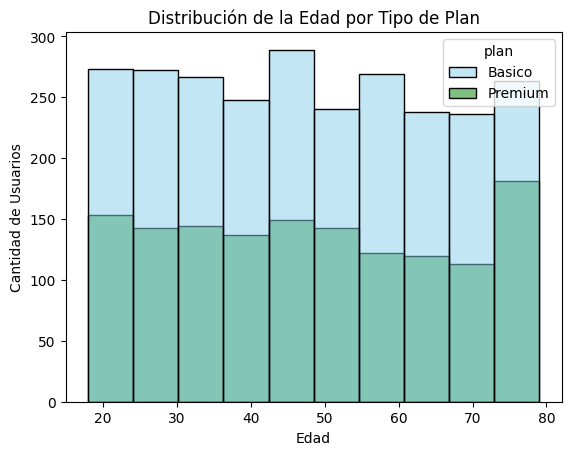

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile,
    x="age",
    hue="plan",
    bins=10,
    palette=["skyblue", "green"]
)

plt.title("Distribución de la Edad por Tipo de Plan")
plt.xlabel("Edad")
plt.ylabel("Cantidad de Usuarios")
plt.show()

💡Insights: 
- Distribución ...La distribución de la edad es aproximadamente simétrica y no se observan diferencias importantes entre los usuarios de los planes Básico y Premium. Ambos planes presentan una distribución de edades similar, por lo que no parece existir una relación clara entre la edad del usuario y el tipo de plan contratado.

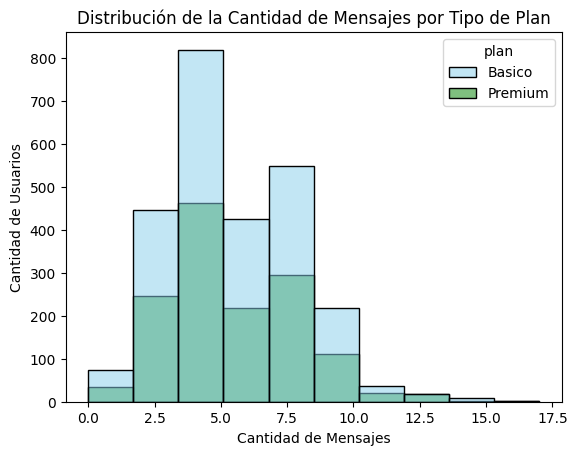

In [44]:
# Histograma para visualizar la cant_mensajes
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma para visualizar la cantidad de mensajes
sns.histplot(
    data=user_profile,
    x="cant_mensajes",
    hue="plan",
    bins=10,
    palette=["skyblue", "green"]
)

plt.title("Distribución de la Cantidad de Mensajes por Tipo de Plan")
plt.xlabel("Cantidad de Mensajes")
plt.ylabel("Cantidad de Usuarios")
plt.show()

💡Insights: 
- .... No se observa un patrón claro entre los planes Básico y Premium respecto a la cantidad de mensajes enviados. La distribución presenta un sesgo hacia la derecha, ya que la mayoría de los usuarios envía pocos mensajes y solo unos pocos envían muchos.

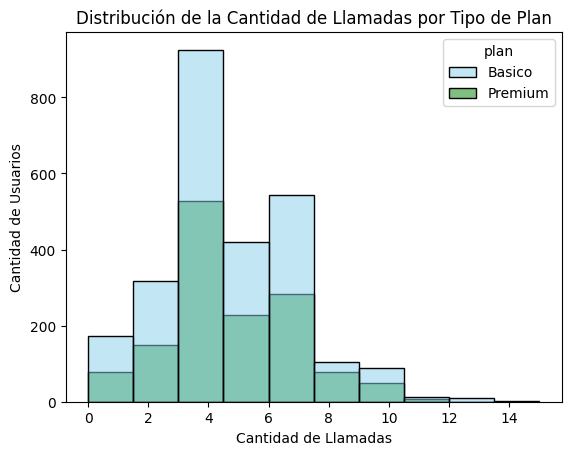

In [45]:
# Histograma para visualizar la cant_llamadas
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma para visualizar la cantidad de llamadas
sns.histplot(
    data=user_profile,
    x="cant_llamadas",
    hue="plan",
    bins=10,
    palette=["skyblue", "green"]
)

plt.title("Distribución de la Cantidad de Llamadas por Tipo de Plan")
plt.xlabel("Cantidad de Llamadas")
plt.ylabel("Cantidad de Usuarios")
plt.show()

💡Insights: 
- Distribución ... Los usuarios del plan Premium tienden a realizar una mayor cantidad de llamadas que los del plan Básico. La distribución está sesgada a la derecha debido a la presencia de usuarios con un alto número de llamadas.

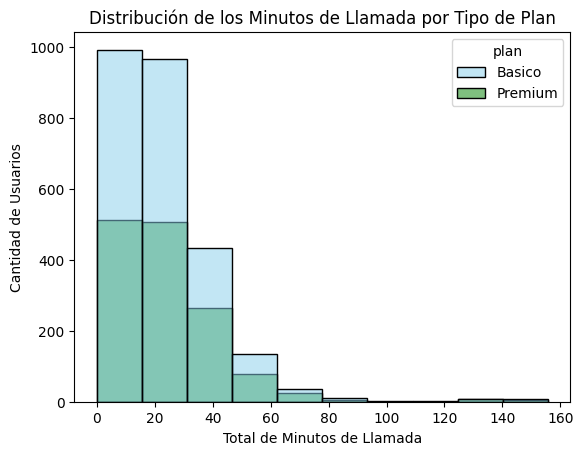

In [46]:

# Histograma para visualizar la cant_minutos_llamada

import matplotlib.pyplot as plt
import seaborn as sns

# Histograma para visualizar la cantidad de minutos de llamada
sns.histplot(
    data=user_profile,
    x="cant_minutos_llamada",
    hue="plan",
    bins=10,
    palette=["skyblue", "green"]
)

plt.title("Distribución de los Minutos de Llamada por Tipo de Plan")
plt.xlabel("Total de Minutos de Llamada")
plt.ylabel("Cantidad de Usuarios")
plt.show()

💡Insights: 
- ... Distribución: No se observa un patrón claro entre los usuarios de los planes Básico y Premium en el total de minutos de llamada. La distribución está sesgada a la derecha, ya que la mayoría de los usuarios acumula pocos minutos y solo un grupo reducido presenta un consumo muy alto.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

In [ ]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for

In [5]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plans = pd.read_csv("/datasets/plans.csv")
users = pd.read_csv("/datasets/users_latam.csv")
usage = pd.read_csv("/datasets/usage.csv")

In [7]:

usage["is_text"] = (usage["type"] == "text").astype(int)
usage["is_call"] = (usage["type"] == "call").astype(int)

usage_agg = (
    usage.groupby("user_id")
    .agg(
        cant_mensajes=("is_text", "sum"),
        cant_llamadas=("is_call", "sum"),
        cant_minutos_llamada=("duration", "sum")
    )
    .reset_index()
)

user_profile = users.merge(usage_agg, on="user_id", how="left")

💡Insights: 

- Age: No presenta outliers significativos.

cant_mensajes: Presenta outliers, con algunos usuarios que envían una cantidad de mensajes muy superior al resto.

cant_llamadas: Presenta outliers, correspondientes a usuarios que realizan un número de llamadas considerablemente mayor que la mayoría.

cant_minutos_llamada: Presenta outliers, ya que algunos usuarios acumulan muchos más minutos de llamada que el resto de los clientes.

In [8]:

# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_superior = Q3 + 1.5 * IQR

    print(f"\n{col}")
    print(f"Q1: {Q1}")
    print(f"Q3: {Q3}")
    print(f"IQR: {IQR}")
    print(f"Límite superior: {limite_superior}")

    outliers = user_profile[user_profile[col] > limite_superior]
    print(f"Número de outliers: {len(outliers)}")



cant_mensajes
Q1: 4.0
Q3: 7.0
IQR: 3.0
Límite superior: 11.5
Número de outliers: 46

cant_llamadas
Q1: 3.0
Q3: 6.0
IQR: 3.0
Límite superior: 10.5
Número de outliers: 30

cant_minutos_llamada
Q1: 11.12
Q3: 31.415
IQR: 20.295
Límite superior: 61.8575
Número de outliers: 109


In [ ]:

# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()
Al comparar los valores máximos con los límites superiores calculados mediante el método IQR, se observa que existen valores que pueden considerarse outliers en algunas variables de uso. Sin embargo, estos valores corresponden a usuarios con un consumo elevado de llamadas o mensajes y representan comportamientos reales del negocio, no errores de captura. Por ello, se decide mantener los outliers en el conjunto de datos, ya que pueden aportar información valiosa para el análisis de patrones de consumo y la segmentación de clientes.

💡Insights: 
cant_mensajes: Mantener los outliers, porque representan usuarios con un volumen de mensajes inusualmente alto. Estos valores pueden reflejar comportamientos reales de uso y son útiles para identificar clientes intensivos.
cant_llamadas: Mantener los outliers, porque corresponden a usuarios que realizan una cantidad de llamadas muy superior al promedio. No hay evidencia de que sean errores de captura, por lo que aportan información valiosa para el análisis.
cant_minutos_llamada: Mantener los outliers, porque reflejan clientes con un consumo elevado de minutos de llamada. Estos casos pueden ser relevantes para la segmentación de usuarios, el análisis de patrones de consumo y la evaluación de los planes ofrecidos.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [9]:
# Crear columna grupo_uso
import numpy as np

# Crear columna grupo_uso
user_profile["grupo_uso"] = np.where(
    (user_profile["cant_llamadas"] < 5) & (user_profile["cant_mensajes"] < 5),
    "Bajo uso",
    np.where(
        (user_profile["cant_llamadas"] < 10) & (user_profile["cant_mensajes"] < 10),
        "Uso medio",
        "Alto uso"
    )
)

# Verificar resultados
user_profile["grupo_uso"].value_counts()

Uso medio    2943
Bajo uso      778
Alto uso      279
Name: grupo_uso, dtype: int64

In [10]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [11]:
# Crear columna grupo_edad
import numpy as np

# Crear columna grupo_edad
user_profile["grupo_edad"] = np.where(
    user_profile["age"] < 30,
    "Joven",
    np.where(
        user_profile["age"] < 60,
        "Adulto",
        "Adulto Mayor"
    )
)

# Verificar resultados
print(user_profile["grupo_edad"].value_counts())

Adulto          1963
Adulto Mayor    1222
Joven            815
Name: grupo_edad, dtype: int64


In [12]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

In [15]:

# Visualización de los segmentos por uso
sns.countplot(...)

plt.show()


AttributeError: 'bool' object has no attribute 'all'

In [17]:

# Visualización de los segmentos por uso
sns.countplot(...)

plt.show()


AttributeError: 'bool' object has no attribute 'all'

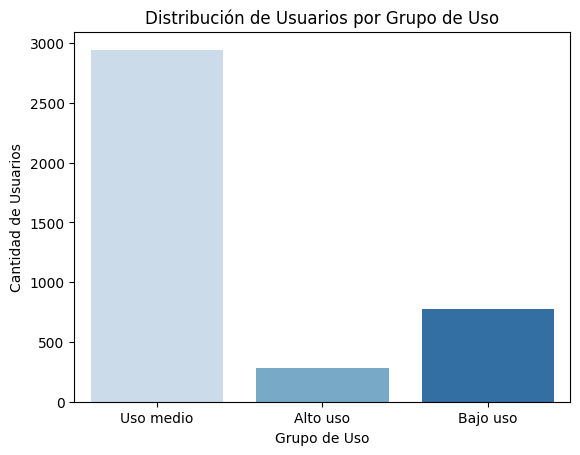

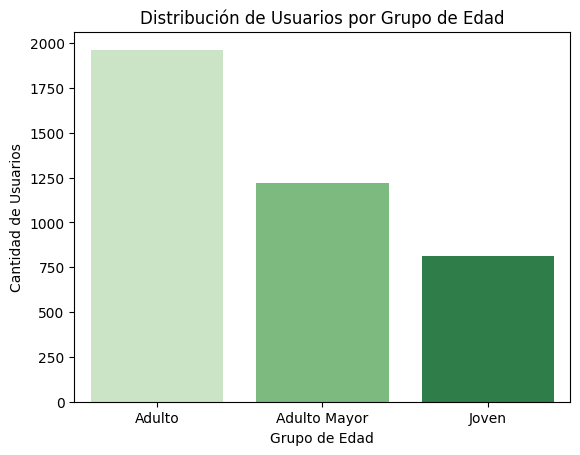

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x="grupo_uso", palette="Blues")

plt.title("Distribución de Usuarios por Grupo de Uso")
plt.xlabel("Grupo de Uso")
plt.ylabel("Cantidad de Usuarios")
plt.show()

# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x="grupo_edad", palette="Greens")

plt.title("Distribución de Usuarios por Grupo de Edad")
plt.xlabel("Grupo de Edad")
plt.ylabel("Cantidad de Usuarios")
plt.show()

In [ ]:

# Visualización de los segmentos por edad



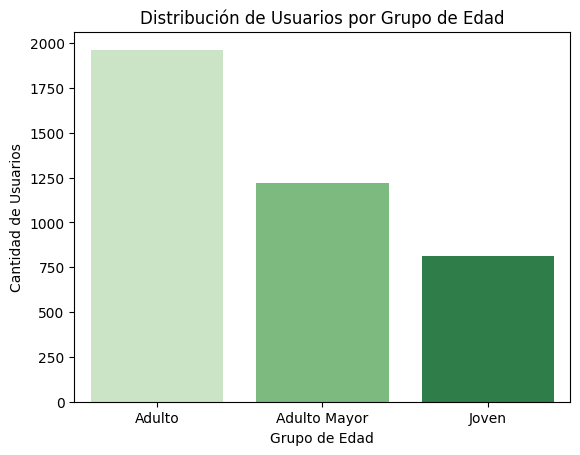

In [19]:
sns.countplot(data=user_profile, x="grupo_edad", palette="Greens")

plt.title("Distribución de Usuarios por Grupo de Edad")
plt.xlabel("Grupo de Edad")
plt.ylabel("Cantidad de Usuarios")

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ Problemas detectados en los datos
Se identificaron valores inválidos, como -999 en la columna age y "?" en la columna city, los cuales fueron corregidos antes del análisis.
También se encontraron fechas fuera del rango de estudio (posteriores a 2024) y valores nulos en duration y length, que se mantuvieron porque dependen del tipo de registro (llamadas o mensajes) y corresponden a valores faltantes esperados.
🔍 Segmentos por Edad
Los usuarios fueron clasificados en Joven, Adulto y Adulto Mayor para facilitar el análisis de su comportamiento.
La mayor parte de los clientes pertenece al grupo de Adultos, mientras que los grupos de Jóvenes y Adultos Mayores representan una menor proporción.
📊 Segmentos por Nivel de Uso
Los usuarios fueron clasificados en Bajo uso, Uso medio y Alto uso, de acuerdo con la cantidad de llamadas y mensajes realizados.
Se identificaron usuarios con un consumo muy superior al promedio (outliers), especialmente en llamadas, mensajes y minutos de conversación. Estos casos representan comportamientos reales y se conservaron en el análisis.

➡️ Esto sugiere que ConnectaTel cuenta con diferentes perfiles de clientes, por lo que una estrategia única para todos los usuarios no sería la más adecuada. La segmentación permite ofrecer productos y beneficios más ajustados a las necesidades de cada grupo.

💡 Recomendaciones
Diseñar planes diferenciados para clientes de bajo, medio y alto uso, ofreciendo mayores beneficios a los usuarios de mayor consumo para mejorar su fidelización.
Implementar controles automáticos de calidad de datos para detectar valores inválidos, fechas fuera de rango y registros inconsistentes antes de realizar futuros análisis.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`